<a href="https://colab.research.google.com/github/gitsd23/customer-churn-prediction-ml/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Customer Churn Prediction Using Machine Learning

This project predicts whether a telecom customer is likely to churn using Machine Learning.

The project was completed as part of my internship at **SkillINFYTech IT Solutions Private Limited**.

### Models Used
- Decision Tree Classifier
- Random Forest Classifier

### Final Model
Random Forest Classifier with balanced class weights

''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

Developed by: Soumadip Das

Linkedin : https://www.linkedin.com/in/soumadip-das-23s09d06/

GitHub : https://github.com/gitsd23

## 🎯 Project Objective

The objective of this project is to develop a Machine Learning model that predicts whether a telecom customer is likely to leave the service based on historical customer information, service usage, contract details, and billing information.

The project also aims to:
- Analyze customer churn patterns.
- Preprocess numerical and categorical data.
- Handle class imbalance.
- Compare Decision Tree and Random Forest models.
- Build a system that can predict churn for a new customer.

Notebook have these main sections:
1. Project Objective
2. Import Libraries
3. Load Dataset
4. Dataset Exploration
5. Data Preprocessing
6. Train-Test Split
7. Feature Encoding
8. Decision Tree Model
9. Random Forest Model
10. Model Comparison
11. Confusion Matrix
12. Feature Importance
13. Custom Customer Prediction
14. Save and Load Final Model
15. Class Imbalance Experiment
16. Final Model Selection
17. Limitations
18. Future Improvements
19. Conclusion

## 2. Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [43]:
from google.colab import files

uploaded = files.upload()

df = pd.read_excel("Telco_customer_churn.xlsx")

## 📂 Dataset Description

The dataset contains information about **7,043 telecom customers** and includes customer demographics, service subscriptions, contract information, billing details, and churn information.

The dataset contains:
- 7,043 customer records
- 33 original columns
- 24 selected predictive features
- Churn Label as the target variable

### Target Variable

- `0` → Customer Stayed
- `1` → Customer Churned


## 3. Load Dataset

In [44]:
pd.read_excel("/content/drive/MyDrive/...")

print("data loaded Succesfully...")
df.head()


data loaded Succesfully...


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices



## 4. Exploratory Data Analysis

In [45]:
print("Data shape :", df.shape)
print("____________")
print(df.columns.tolist())
print("_________________")

Data shape : (7043, 33)
____________
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
_________________



### 4.1 Dataset Shape

### 4.2 Dataset Information

### 4.3 Missing Values

### 4.4 Duplicate Values

### 4.5 Churn Distribution

In [46]:
# Basic Dataset Information


print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nChurn Distribution:")
print(df["Churn Label"].value_counts())

print("\nChurn Percentage:")
print(df["Churn Label"].value_counts(normalize=True) * 100)

Dataset Shape: (7043, 33)

Data Types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtyp


## 5. Data Preprocessing

In [47]:
print(df["Churn Label"].value_counts()/df["Churn Label"].value_counts().sum())

Churn Label
No     0.73463
Yes    0.26537
Name: count, dtype: float64


### 5.1 Feature Selection

In [48]:


# Target variable
y = df["Churn Label"]

# Remove columns that should not be used as features
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

X = df.drop(columns=columns_to_drop)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nRemaining Features:")
print(X.columns.tolist())

Feature Shape: (7043, 24)
Target Shape: (7043,)

Remaining Features:
['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


### 5.2 Convert Total Charges

In [49]:

X["Total Charges"] = pd.to_numeric(
    X["Total Charges"],
    errors="coerce"
)

print("Total Charges Data Type:")
print(X["Total Charges"].dtype)

print("\nMissing Values in Total Charges:")
print(X["Total Charges"].isnull().sum())

Total Charges Data Type:
float64

Missing Values in Total Charges:
11


### 5.3 Handle Missing Values

In [50]:
print("Missing values before handling:")
print(X.isnull().sum()[X.isnull().sum() > 0])

# Fill missing Total Charges with the median
X["Total Charges"] = X["Total Charges"].fillna(
    X["Total Charges"].median()
)

print("\nMissing values after handling:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Missing values before handling:
Total Charges    11
dtype: int64

Missing values after handling:
Series([], dtype: int64)


### 5.4 Encode Target Variable

In [51]:
y = y.map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())

Churn Label
0    5174
1    1869
Name: count, dtype: int64


## 6. Train-Test Split

In [52]:
# ==========================================
# Import Required Libraries
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# ==========================================
# Identify Feature Types
# ==========================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Numerical Features:
['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


In [53]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training Data Shape: (5634, 24)
Testing Data Shape: (1409, 24)

Training Target Distribution:
Churn Label
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing Target Distribution:
Churn Label
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [54]:
# ==========================================
# Create Preprocessing Pipeline
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [55]:
# ==========================================
# Decision Tree Classifier
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Create Decision Tree model
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced",
                max_depth=10
            )
        )
    ]
)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully!")

✅ Decision Tree model trained successfully!


In [56]:
# ==========================================
# Decision Tree Predictions
# ==========================================

y_pred_dt = decision_tree_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_dt))

Predictions generated successfully!
Number of predictions: 1409


In [57]:
# ==========================================
# Decision Tree Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Stayed", "Churned"]
))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 73.53%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.73      0.80      1035
     Churned       0.50      0.74      0.60       374

    accuracy                           0.74      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.78      0.74      0.75      1409


Confusion Matrix:
[[759 276]
 [ 97 277]]


In [58]:
# ==========================================
# Random Forest Classifier
# ==========================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


## 🔍 Feature Importance

Feature importance helps identify which customer attributes contribute most to the Random Forest model's predictions.

In [59]:
# ==========================================
# Random Forest Predictions
# ==========================================

y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))

Predictions generated successfully!
Number of predictions: 1409


In [60]:
# ==========================================
# Random Forest Evaluation
# ==========================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Stayed", "Churned"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 79.77%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1035
     Churned       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[931 104]
 [181 193]]


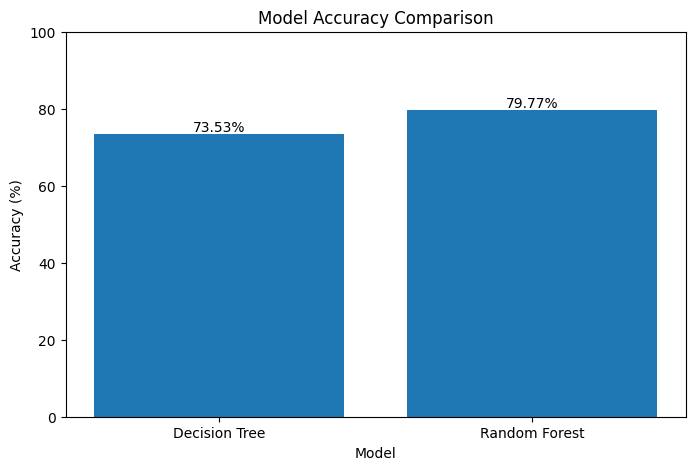

In [61]:
# ==========================================
# Model Comparison
# ==========================================

models = ["Decision Tree", "Random Forest"]

accuracies = [
    dt_accuracy * 100,
    rf_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.show()

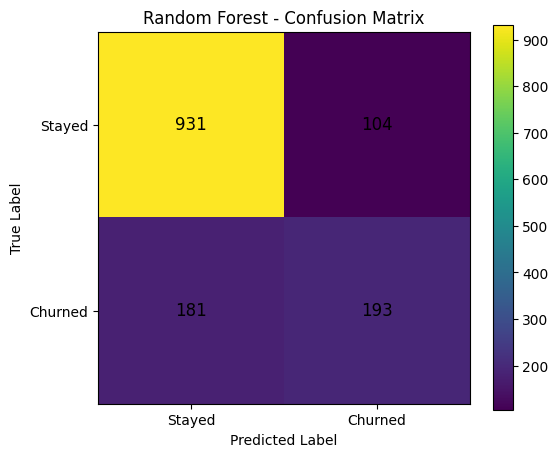

In [64]:
# ==========================================
# Random Forest Confusion Matrix
# ==========================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

plt.imshow(cm_rf, interpolation="nearest")

plt.title("Random Forest - Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Stayed", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Stayed", "Churned"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(
            j,
            i,
            str(cm_rf[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.show()


In [65]:
# ==========================================
# Custom Customer Churn Prediction
# ==========================================

def predict_customer_churn(customer_data):

    # Convert input dictionary into DataFrame
    customer_df = pd.DataFrame([customer_data])

    # Make prediction
    prediction = random_forest_model.predict(customer_df)[0]

    # Get prediction probability
    probability = random_forest_model.predict_proba(
        customer_df
    )[0]

    if prediction == 1:
        result = "Customer Likely to Churn"
    else:
        result = "Customer Likely to Stay"

    return {
        "Prediction": result,
        "Stay Probability": f"{probability[0]:.2%}",
        "Churn Probability": f"{probability[1]:.2%}"
    }

In [66]:
sample_customer = {
    "City": "Los Angeles",
    "Zip Code": 90001,
    "Latitude": 34.05,
    "Longitude": -118.25,
    "Gender": "Male",
    "Senior Citizen": "No",
    "Partner": "No",
    "Dependents": "No",
    "Tenure Months": 2,
    "Phone Service": "Yes",
    "Multiple Lines": "No",
    "Internet Service": "Fiber optic",
    "Online Security": "No",
    "Online Backup": "No",
    "Device Protection": "No",
    "Tech Support": "No",
    "Streaming TV": "No",
    "Streaming Movies": "No",
    "Contract": "Month-to-month",
    "Paperless Billing": "Yes",
    "Payment Method": "Electronic check",
    "Monthly Charges": 70.00,
    "Total Charges": 140.00,
    "CLTV": 4000
}

result = predict_customer_churn(sample_customer)

print("Prediction Result:")
print(result)

Prediction Result:
{'Prediction': 'Customer Likely to Churn', 'Stay Probability': '26.50%', 'Churn Probability': '73.50%'}


In [67]:
# ==========================================
# Save Final Customer Churn Model
# ==========================================

import joblib

joblib.dump(
    random_forest_model,
    "customer_churn_model.pkl"
)

print("✅ Customer Churn Model saved successfully!")

✅ Customer Churn Model saved successfully!


In [68]:
# ==========================================
# Load and Test Saved Model
# ==========================================

loaded_model = joblib.load(
    "customer_churn_model.pkl"
)

# Predict using the loaded model
loaded_prediction = loaded_model.predict(
    pd.DataFrame([sample_customer])
)[0]

loaded_probability = loaded_model.predict_proba(
    pd.DataFrame([sample_customer])
)[0]

if loaded_prediction == 1:
    print("Prediction: Customer Likely to Churn")
else:
    print("Prediction: Customer Likely to Stay")

print(f"Stay Probability: {loaded_probability[0]:.2%}")
print(f"Churn Probability: {loaded_probability[1]:.2%}")

Prediction: Customer Likely to Churn
Stay Probability: 26.50%
Churn Probability: 73.50%


In [69]:
# ==========================================
# Final Model Summary
# ==========================================

print("==========================================")
print("FINAL MODEL PERFORMANCE")
print("==========================================")

print(f"Model: Random Forest Classifier")
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

print("\nChurn Class Performance:")
print("Precision: 0.65")
print("Recall: 0.52")
print("F1-Score: 0.58")

print("\nDataset:")
print(f"Total Customers: {len(df)}")

print("\nPrediction System:")
print("✅ New customer prediction supported")
print("✅ Churn probability supported")

FINAL MODEL PERFORMANCE
Model: Random Forest Classifier
Accuracy: 79.77%

Churn Class Performance:
Precision: 0.65
Recall: 0.52
F1-Score: 0.58

Dataset:
Total Customers: 7043

Prediction System:
✅ New customer prediction supported
✅ Churn probability supported


## Experiment: Alternative Class Weighting

To further investigate the effect of class imbalance, an additional Random Forest model was trained by assigning a higher weight to the churned class.

The results were compared with the balanced Random Forest model.

In [70]:
# ==========================================
# Random Forest with Higher Churn Weight
# ==========================================

random_forest_weighted = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight={0: 1, 1: 2},
                n_jobs=-1
            )
        )
    ]
)

# Train the weighted model
random_forest_weighted.fit(X_train, y_train)

print("✅ Weighted Random Forest trained successfully!")

✅ Weighted Random Forest trained successfully!


In [71]:
# ==========================================
# Predictions
# ==========================================

y_pred_weighted = random_forest_weighted.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [72]:
# ==========================================
# Weighted Random Forest Evaluation
# ==========================================

weighted_accuracy = accuracy_score(
    y_test,
    y_pred_weighted
)

print(
    f"Weighted Random Forest Accuracy: "
    f"{weighted_accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_weighted,
        target_names=["Stayed", "Churned"]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_weighted
    )
)

Weighted Random Forest Accuracy: 79.49%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.87      1035
     Churned       0.65      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Confusion Matrix:
[[931 104]
 [185 189]]


### Observation

The weighted Random Forest achieved 79.49% accuracy with a churn recall of 51%.

The balanced Random Forest achieved 79.77% accuracy with a churn recall of 52%.

Therefore, the balanced Random Forest was selected as the final model.

In [73]:
# ==========================================
# Save Final Balanced Random Forest Model
# ==========================================

import joblib

joblib.dump(
    random_forest_model,
    "customer_churn_model.pkl"
)

print("✅ Final Customer Churn Model saved successfully!")

✅ Final Customer Churn Model saved successfully!


## 🏆 Final Model Selection

After comparing the Decision Tree and Random Forest models, the Random Forest Classifier with balanced class weights was selected as the final model.

| Model | Accuracy | Churn Recall | Churn F1-Score |
|---|---:|---:|---:|
| Decision Tree | 73.53% | 74% | 0.60 |
| Random Forest (Balanced) | 79.77% | 52% | 0.58 |
| Random Forest (Churn Weight = 2) | 79.49% | 51% | 0.57 |

The Random Forest with balanced class weights achieved the highest overall accuracy of **79.77%** and was selected as the final model.

Although the Decision Tree achieved higher recall for the churned class, the Random Forest provided better overall predictive performance.

## ⚠️ Limitations

- The model achieved 79.77% overall accuracy, but the recall for the churned class was 52%.
- This means the model still misses a portion of customers who actually churn.
- The dataset represents a specific telecom customer population, so performance may vary on other datasets.
- The model relies on historical customer information and may not fully capture changes in customer behavior over time.
- The current model does not use advanced hyperparameter optimization or advanced sampling techniques.

## 🔮 Future Improvements

Future versions of this project can be improved by:

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Testing advanced boosting algorithms such as XGBoost or LightGBM.
- Applying SMOTE or other resampling techniques.
- Optimizing the prediction threshold to improve churn recall.
- Performing feature importance analysis.
- Building an interactive Streamlit web application.
- Deploying the model as a web service.

## 📝 Conclusion

This project successfully developed a Machine Learning-based customer churn prediction system.

Two tree-based models, Decision Tree and Random Forest, were trained and evaluated. The Random Forest Classifier with balanced class weights achieved the best overall accuracy of **79.77%**.

The project also includes a custom prediction system that accepts new customer information and predicts whether the customer is likely to churn, along with the estimated probability of churn.

The project provided practical experience in data preprocessing, categorical feature encoding, imbalanced classification, model evaluation, and building a complete Machine Learning pipeline.